In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


In [4]:
data = pd.read_csv('../data/marketing_AB.csv')

In [5]:
df = data.copy()

##**Inspection**

In [6]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [7]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [8]:
df = df.drop(columns=['Unnamed: 0'])

# Sanity checks
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['user id'].duplicated().sum())  # check for duplicate users

(588101, 6)
user id          int64
test group         str
converted         bool
total ads        int64
most ads day       str
most ads hour    int64
dtype: object
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64
0


In [9]:
# 1. Check duplicate users
print("Duplicate users:", df['user id'].duplicated().sum())
print("Unique users:", df['user id'].nunique())
print("Total rows:", len(df))

# 2. Group sizes
group_counts = df['test group'].value_counts()

print("\nGroup Sizes:")
print(group_counts)

print("\nGroup Percentages:")
print((group_counts / len(df) * 100).round(2))

# 3. Overall conversions
total_conversions = df['converted'].sum()
total_users = len(df)
conversion_rate = df['converted'].mean()

print("\nOverall Conversions:")
print(f"Converted users: {total_conversions:,}")
print(f"Total users: {total_users:,}")
print(f"Overall conversion rate: {conversion_rate:.2%}")

group_summary = df.groupby('test group')['converted'].agg(
    users='count',
    conversions='sum',
    conversion_rate='mean'
)

group_summary['conversion_rate'] *= 100
print("\n")
print(group_summary)

Duplicate users: 0
Unique users: 588101
Total rows: 588101

Group Sizes:
test group
ad     564577
psa     23524
Name: count, dtype: int64

Group Percentages:
test group
ad     96.0
psa     4.0
Name: count, dtype: float64

Overall Conversions:
Converted users: 14,843
Total users: 588,101
Overall conversion rate: 2.52%


             users  conversions  conversion_rate
test group                                      
ad          564577        14423         2.554656
psa          23524          420         1.785411


##**Exploratory Data Analysis (EDA)**

In [10]:
# Overall distribution of total ads seen
print('Total Ads - Overall:')
print(df['total ads'].describe())
print()

# Distribution of total ads by experiment group
print('Total Ads - By Group:')
print(df.groupby('test group')['total ads'].describe())
print()

# Conversion rate by day with the most ads
print('Conversion Rate by Most Ads Day:')
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

by_day = (
    df.groupby('most ads day')['converted']
      .agg(['mean', 'count'])
      .reindex(day_order)
)

by_day['mean'] = by_day['mean'] * 100
by_day.rename(columns={
    'mean': 'conversion_rate',
    'count': 'users'
}, inplace=True)

print(by_day)
print()

# Conversion rate by hour with the most ads
print('Conversion Rate by Most Ads Hour:')
by_hour = df.groupby('most ads hour')['converted'].mean() * 100

print(by_hour)

Total Ads - Overall:
count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64

Total Ads - By Group:
               count       mean        std  min  25%   50%   75%     max
test group                                                              
ad          564577.0  24.823365  43.750456  1.0  4.0  13.0  27.0  2065.0
psa          23524.0  24.761138  42.860720  1.0  4.0  12.0  26.0   907.0

Conversion Rate by Most Ads Day:
              conversion_rate  users
most ads day                        
Monday               3.281155  87073
Tuesday              2.984034  77479
Wednesday            2.494191  80908
Thursday             2.157094  82982
Friday               2.221190  92608
Saturday             2.105070  81660
Sunday               2.447565  85391

Conversion Rate by Most Ads Hour:
most ads hour
0     1.842486
1     1.291129
2 

In [11]:
conversion_by_day = (
    df.groupby('most ads day')['converted']
      .mean()
      .reindex(day_order)
      * 100
)

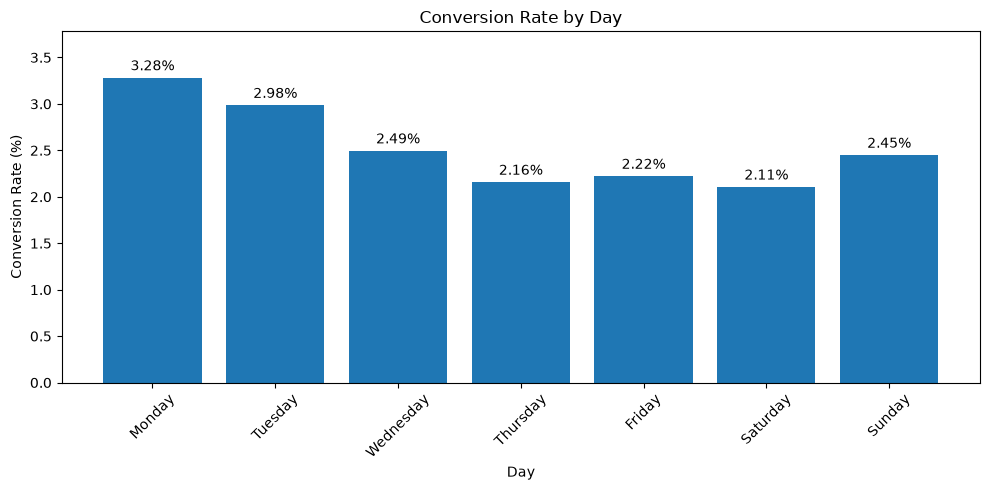

In [12]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

conversion_by_day = (
    df.groupby('most ads day')['converted']
      .mean()
      .reindex(day_order) * 100
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(conversion_by_day.index, conversion_by_day.values)

# Add percentage labels
ax.bar_label(
    bars,
    labels=[f'{v:.2f}%' for v in conversion_by_day.values],
    padding=3
)

ax.set_xlabel('Day')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Day')
ax.set_ylim(0, conversion_by_day.max() + 0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

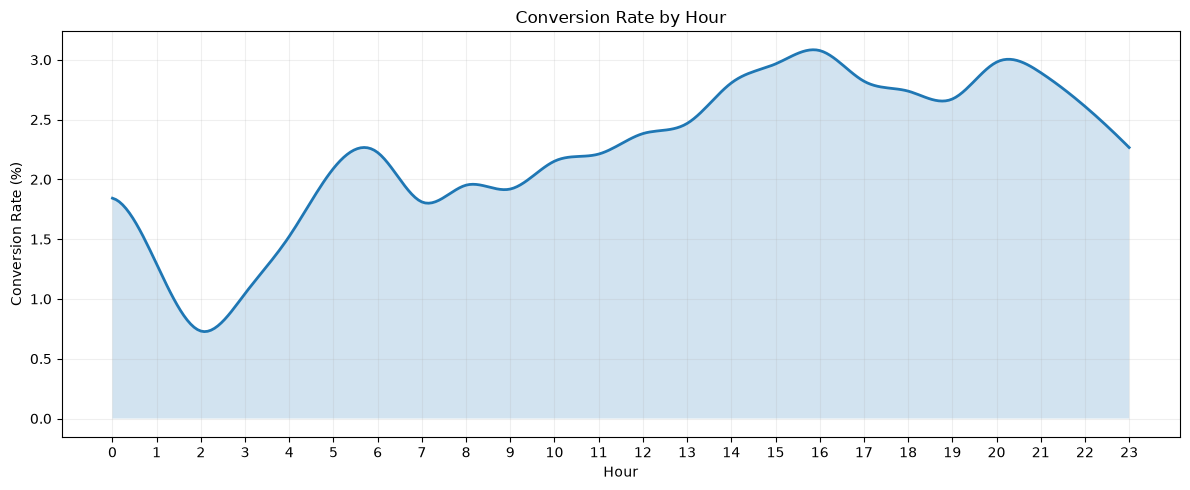

In [13]:
from scipy.interpolate import make_interp_spline

conversion_by_hour = (
    df.groupby('most ads hour')['converted']
      .mean() * 100
)

x = conversion_by_hour.index.values
y = conversion_by_hour.values

# Smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

# Plot
plt.figure(figsize=(12, 5))

plt.plot(x_smooth, y_smooth, linewidth=2)
plt.fill_between(x_smooth, y_smooth, alpha=0.2)

plt.xlabel('Hour')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Hour')

plt.xticks(range(0, 24))
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Exploratory Analysis

- **Ad exposure distribution:** The distribution of `total ads` is nearly identical between the control and test groups, with both groups having a mean of approximately 24.8 ads and similar quartiles. This suggests that the two groups are comparable in terms of ad exposure intensity, reducing the likelihood that differences in conversion are driven simply by unequal ad exposure.

- **Right-skewed ad exposure:** `total ads` is heavily right-skewed. The median is only 13 ads, compared with a mean of approximately 24.8, while the maximum reaches 2,065 ads. This indicates that a small number of users were exposed to a very large number of ads. This skewness should be considered in later analysis, as these high-exposure users could potentially influence conversion-related results.

- **Conversion rate by day:** Conversion rate varies across days of the week. It is highest on Monday and Tuesday at around 3%, while it is lowest on Thursday and Saturday at approximately 2.1–2.2%.

- **Conversion rate by hour:** Conversion rate also varies significantly by hour. It is lowest during the overnight period, reaching approximately 0.7% around 2 AM. It then gradually increases throughout the day and reaches its highest levels during the afternoon and evening, at around 3% between 4 PM and 8 PM.

> **Important:** The day-of-week and hourly patterns represent overall conversion behavior across all users. They have not yet been separated by the `ad` and `psa` groups. Therefore, these patterns should **not** be interpreted as evidence that ads perform better at specific times of day. The effect of ad exposure needs to be analyzed separately within the A/B test groups.

##**Randomization and Covariate Balance Check**


In [14]:
# 1. Compare total ads distribution between groups
# Mann-Whitney U is used because total ads is heavily right-skewed
ad_total = df[df['test group'] == 'ad']['total ads']
psa_total = df[df['test group'] == 'psa']['total ads']

u_stat, p_mw = stats.mannwhitneyu(
    ad_total,
    psa_total,
    alternative='two-sided'
)

print('Mann-Whitney U test on total ads (ad vs psa):')
print(f'  p-value = {p_mw:.4f}')
print()

# 2. Chi-square test: Is most ads day independent of test group?
day_ct = pd.crosstab(
    df['test group'],
    df['most ads day']
)

chi2, p_day, dof, expected = stats.chi2_contingency(day_ct)

print('Chi-square test: most ads day vs test group:')
print(f'  chi2 = {chi2:.2f}, p-value = {p_day:.4f}')
print()

# 3. Chi-square test: Is most ads hour independent of test group?
hour_ct = pd.crosstab(
    df['test group'],
    df['most ads hour']
)

chi2h, p_hour, dofh, expected_hour = stats.chi2_contingency(hour_ct)

print('Chi-square test: most ads hour vs test group:')
print(f'  chi2 = {chi2h:.2f}, p-value = {p_hour:.4f}')

Mann-Whitney U test on total ads (ad vs psa):
  p-value = 0.0000

Chi-square test: most ads day vs test group:
  chi2 = 235.61, p-value = 0.0000

Chi-square test: most ads hour vs test group:
  chi2 = 192.29, p-value = 0.0000


### Covariate Balance Test Results

The statistical tests show significant differences between the `ad` and `psa` groups across all three examined variables:

- **Total ads:** The Mann–Whitney U test gives a p-value of `< 0.001`, indicating that the distribution of ad exposure differs significantly between the two groups.
- **Most ads day:** The chi-square test gives `χ² = 235.61` with `p < 0.001`, indicating that the distribution of users' highest-ad-exposure day differs significantly between groups.
- **Most ads hour:** The chi-square test gives `χ² = 192.29` with `p < 0.001`, indicating that the distribution of users' highest-ad-exposure hour also differs significantly between groups.

These results suggest that the `ad` and `psa` groups are **not perfectly balanced on these observed covariates**. However, statistical significance alone does not necessarily imply that the imbalance is practically important, particularly with a large sample size.

Therefore, the next step is to examine the **magnitude of the differences** using descriptive statistics and effect sizes, rather than relying only on p-values. This will help determine whether the observed imbalances are large enough to meaningfully affect the causal comparison between the two groups.

In [15]:
# --------------------------------------------------
# 1. Effect size for total ads
# --------------------------------------------------

ad_total = df[df['test group'] == 'ad']['total ads']
psa_total = df[df['test group'] == 'psa']['total ads']

print("Total Ads Comparison")
print("-" * 30)
print(f"Median total ads - Ad:  {ad_total.median():.1f}")
print(f"Median total ads - PSA: {psa_total.median():.1f}")
print(f"Mean total ads   - Ad:  {ad_total.mean():.2f}")
print(f"Mean total ads   - PSA: {psa_total.mean():.2f}")
print()


# --------------------------------------------------
# 2. Cramér's V for categorical variables
# --------------------------------------------------

def cramers_v(contingency_table):
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

    n = contingency_table.sum().sum()
    rows, columns = contingency_table.shape

    return np.sqrt(
        chi2 / (n * min(rows - 1, columns - 1))
    )


# Most ads day vs test group
day_ct = pd.crosstab(
    df['test group'],
    df['most ads day']
)

day_v = cramers_v(day_ct)

print("Cramér's V - Most Ads Day vs Test Group")
print(f"Cramér's V = {day_v:.4f}")
print()


# Most ads hour vs test group
hour_ct = pd.crosstab(
    df['test group'],
    df['most ads hour']
)

hour_v = cramers_v(hour_ct)

print("Cramér's V - Most Ads Hour vs Test Group")
print(f"Cramér's V = {hour_v:.4f}")

Total Ads Comparison
------------------------------
Median total ads - Ad:  13.0
Median total ads - PSA: 12.0
Mean total ads   - Ad:  24.82
Mean total ads   - PSA: 24.76

Cramér's V - Most Ads Day vs Test Group
Cramér's V = 0.0200

Cramér's V - Most Ads Hour vs Test Group
Cramér's V = 0.0181


### Interpretation and Conclusion

**Interpretation:** All three p-values are extremely small; however, this is largely a consequence of the very large sample size (~588K rows). With such a large dataset, even very small differences can become statistically significant. Therefore, statistical significance alone should not be treated as evidence of a meaningful imbalance.

The **effect sizes** provide a more useful perspective. Cramér's V is close to zero for both `most ads day` (`0.0200`) and `most ads hour` (`0.0181`), indicating negligible associations. Similarly, the mean and median `total ads` values are almost identical between the two groups.

**Conclusion:** There is no evidence of a **meaningfully broken or biased randomization** based on these observed covariates. The `ad` and `psa` groups are well-balanced in terms of ad exposure, day, and hour. Therefore, the observed difference in conversion rates is unlikely to be explained by these variables, allowing us to proceed with testing the **actual treatment hypothesis** in the next step.

##**Run the significance test**

In [22]:
# --------------------------------------------------
# 1. Get conversion counts
# --------------------------------------------------

counts = df.groupby('test group')['converted'].agg(['sum', 'count'])

x_ad = counts.loc['ad', 'sum']
n_ad = counts.loc['ad', 'count']

x_psa = counts.loc['psa', 'sum']
n_psa = counts.loc['psa', 'count']

p_ad = x_ad / n_ad
p_psa = x_psa / n_psa

print("Conversion Rates")
print("-" * 40)
print(f"Ad:  {p_ad:.5f} ({x_ad}/{n_ad})")
print(f"PSA: {p_psa:.5f} ({x_psa}/{n_psa})")
print()


# --------------------------------------------------
# 2. Two-Proportion Z-Test
# --------------------------------------------------

count = [x_ad, x_psa]
nobs = [n_ad, n_psa]

z_stat, p_two_sided = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='two-sided'
)

# One-sided test: H1 = p_ad > p_psa
z_stat_one, p_one_sided = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='larger'
)

print("Two-Proportion Z-Test")
print("-" * 40)
print(f"Z-statistic: {z_stat:.4f}")
print(f"One-sided p-value (Ad > PSA): {p_one_sided:.2e}")
print(f"Two-sided p-value: {p_two_sided:.2e}")
print()


# --------------------------------------------------
# 3. 95% Confidence Interval
# --------------------------------------------------

ci_low, ci_high = confint_proportions_2indep(
    count1=x_ad,
    nobs1=n_ad,
    count2=x_psa,
    nobs2=n_psa,
    compare='diff',
    method='wald'
)

difference = p_ad - p_psa

print("Conversion Rate Difference")
print("-" * 40)
print(f"Difference (Ad - PSA): {difference:.5f}")
print(f"Difference in percentage points: {difference * 100:.3f} pp")
print(f"95% CI: [{ci_low:.5f}, {ci_high:.5f}]")
print(
    f"95% CI in percentage points: "
    f"[{ci_low * 100:.3f}, {ci_high * 100:.3f}] pp"
)
print()


# --------------------------------------------------
# 4. Chi-Square Test
# --------------------------------------------------

ct = pd.crosstab(
    df['test group'],
    df['converted']
)

chi2, p_chi2, dof, expected = chi2_contingency(
    ct,
    correction=False
)

print("Chi-Square Test (Cross-Check)")
print("-" * 40)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_chi2:.2e}")

Conversion Rates
----------------------------------------
Ad:  0.02555 (14423/564577)
PSA: 0.01785 (420/23524)

Two-Proportion Z-Test
----------------------------------------
Z-statistic: 7.3701
One-sided p-value (Ad > PSA): 8.53e-14
Two-sided p-value: 1.71e-13

Conversion Rate Difference
----------------------------------------
Difference (Ad - PSA): 0.00769
Difference in percentage points: 0.769 pp
95% CI: [0.00595, 0.00943]
95% CI in percentage points: [0.595, 0.943] pp

Chi-Square Test (Cross-Check)
----------------------------------------
Chi-square statistic: 54.32
P-value: 1.71e-13


Ad conversion rate:  2.5547%
PSA conversion rate: 1.7854%

Observed Z-statistic: 7.3701
One-sided p-value: 8.53e-14
Critical Z (α = 0.05): 1.6449


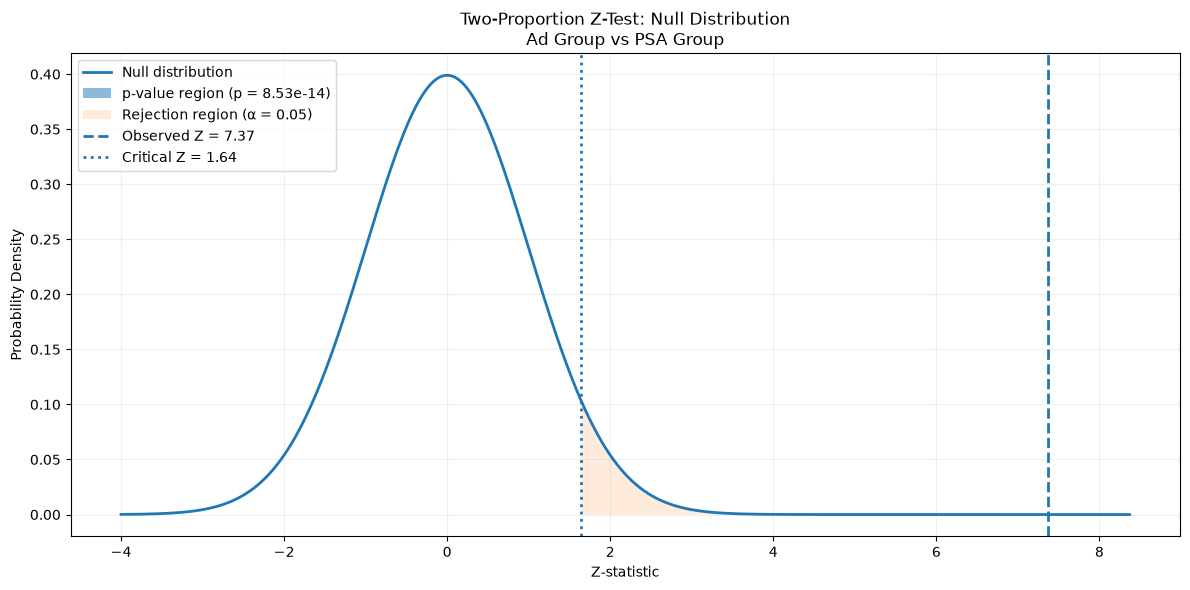

In [23]:
# --------------------------------------------------
# 1. Get conversion counts
# --------------------------------------------------

counts = df.groupby('test group')['converted'].agg(['sum', 'count'])

x_ad = counts.loc['ad', 'sum']
n_ad = counts.loc['ad', 'count']

x_psa = counts.loc['psa', 'sum']
n_psa = counts.loc['psa', 'count']

# Conversion rates
p_ad = x_ad / n_ad
p_psa = x_psa / n_psa

print(f"Ad conversion rate:  {p_ad:.4%}")
print(f"PSA conversion rate: {p_psa:.4%}")

# --------------------------------------------------
# 2. Two-proportion Z-test
# H0: p_ad <= p_psa
# H1: p_ad > p_psa
# --------------------------------------------------

count = [x_ad, x_psa]
nobs = [n_ad, n_psa]

z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative='larger'
)

print(f"\nObserved Z-statistic: {z_stat:.4f}")
print(f"One-sided p-value: {p_value:.2e}")

# --------------------------------------------------
# 3. Critical Z value for alpha = 0.05
# --------------------------------------------------

alpha = 0.05

z_critical = stats.norm.ppf(1 - alpha)

print(f"Critical Z (α = 0.05): {z_critical:.4f}")

# --------------------------------------------------
# 4. Create standard normal distribution
# --------------------------------------------------

# Make sure the plot extends beyond the observed Z
z_max = max(5, z_stat + 1)

z = np.linspace(-4, z_max, 3000)
pdf = stats.norm.pdf(z)

# --------------------------------------------------
# 5. Plot
# --------------------------------------------------

plt.figure(figsize=(12, 6))

# Null distribution
plt.plot(
    z,
    pdf,
    linewidth=2,
    label='Null distribution'
)

# --------------------------------------------------
# 6. Shade p-value region
# --------------------------------------------------

z_pvalue = z[z >= z_stat]

plt.fill_between(
    z_pvalue,
    stats.norm.pdf(z_pvalue),
    0,
    alpha=0.5,
    label=f'p-value region (p = {p_value:.2e})'
)

# --------------------------------------------------
# 7. Shade rejection region
# --------------------------------------------------

z_rejection = z[z >= z_critical]

plt.fill_between(
    z_rejection,
    stats.norm.pdf(z_rejection),
    0,
    alpha=0.15,
    label=f'Rejection region (α = {alpha})'
)

# --------------------------------------------------
# 8. Observed Z-statistic
# --------------------------------------------------

plt.axvline(
    z_stat,
    linestyle='--',
    linewidth=2,
    label=f'Observed Z = {z_stat:.2f}'
)

# --------------------------------------------------
# 9. Critical Z
# --------------------------------------------------

plt.axvline(
    z_critical,
    linestyle=':',
    linewidth=2,
    label=f'Critical Z = {z_critical:.2f}'
)

# --------------------------------------------------
# 10. Labels and formatting
# --------------------------------------------------

plt.xlabel('Z-statistic')
plt.ylabel('Probability Density')

plt.title(
    'Two-Proportion Z-Test: Null Distribution\n'
    'Ad Group vs PSA Group'
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Verdict: Statistically Significant

The hypothesis test provides **strong evidence of a difference in conversion rates** between the two groups. Since the p-value is far below the significance level of $\alpha = 0.05$, we **reject the null hypothesis** that the conversion rates are equal.

The `ad` group has a higher conversion rate than the `psa` group, and this difference is unlikely to be explained by random chance. Since the covariate balance analysis in Step 4 showed that the groups are well-balanced on the observed variables, there is no strong evidence that these factors are responsible for the observed conversion difference.

As a cross-check, a chi-square test on the same $2 \times 2$ contingency table produced $\chi^2 = 54.32$ with $p = 1.7 \times 10^{-13}$. This agrees with the two-sided z-test, as expected, since the two tests are mathematically equivalent for a two-group comparison with a binary outcome.

**Important:** The 95% confidence interval for the difference is approximately **[0.60 pp, 0.94 pp]**. This provides a plausible range for the true improvement in conversion rate and is more informative than the p-value alone. With nearly 588K observations, even very small differences can become statistically significant. In this case, however, the estimated effect is both **statistically significant and practically meaningful**, corresponding to approximately a **43% relative lift in conversion rate** for the `ad` group.

##**Business Impact**

In [21]:
# --------------------------------------------------
# 1. Calculate conversion rates
# --------------------------------------------------

counts = df.groupby('test group')['converted'].agg(['sum', 'count'])

x_ad = counts.loc['ad', 'sum']
n_ad = counts.loc['ad', 'count']

x_psa = counts.loc['psa', 'sum']
n_psa = counts.loc['psa', 'count']

p_ad = x_ad / n_ad
p_psa = x_psa / n_psa

# Conversion rate difference
diff = p_ad - p_psa


# --------------------------------------------------
# 2. Incremental conversions
# --------------------------------------------------

# 95% CI obtained from the hypothesis testing step
ci_low = 0.00595
ci_high = 0.00943

# Point estimate and confidence interval
incremental_point = diff * n_ad
incremental_low = ci_low * n_ad
incremental_high = ci_high * n_ad

print("Incremental Conversions")
print("-" * 40)
print(f"Point estimate: {incremental_point:,.0f}")
print(
    f"95% CI: {incremental_low:,.0f} - "
    f"{incremental_high:,.0f}"
)
print()


# --------------------------------------------------
# 3. Revenue Sensitivity Analysis
# --------------------------------------------------

margins = [20, 50, 100, 200]

print("Revenue Sensitivity Analysis")
print("-" * 60)
print(
    f"Based on estimated incremental conversions: "
    f"{incremental_point:,.0f}"
)

for margin in margins:
    revenue_point = incremental_point * margin
    revenue_low = incremental_low * margin
    revenue_high = incremental_high * margin

    print(
        f"Margin per conversion ${margin:>3}: "
        f"${revenue_point:>12,.0f} "
        f"(95% CI: ${revenue_low:,.0f} - "
        f"${revenue_high:,.0f})"
    )

print()


# --------------------------------------------------
# 4. Conversion Rate by Day
# --------------------------------------------------

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_data = (
    df.groupby(['most ads day', 'test group'])['converted']
      .agg(['sum', 'count'])
      .reindex(day_order, level=0)
)

print("Conversion Rate by Day")
print("-" * 60)

for day in day_order:

    # Ad group
    ad_conversions = day_data.loc[(day, 'ad'), 'sum']
    ad_users = day_data.loc[(day, 'ad'), 'count']

    # PSA group
    psa_conversions = day_data.loc[(day, 'psa'), 'sum']
    psa_users = day_data.loc[(day, 'psa'), 'count']

    # Conversion rates
    ad_rate = ad_conversions / ad_users
    psa_rate = psa_conversions / psa_users

    # Absolute lift
    lift = ad_rate - psa_rate

    print(
        f"{day:<10} "
        f"Ad = {ad_rate * 100:.2f}%  "
        f"PSA = {psa_rate * 100:.2f}%  "
        f"Lift = {lift * 100:+.2f}pp  "
        f"(PSA n = {psa_users:,.0f})"
    )

Incremental Conversions
----------------------------------------
Point estimate: 4,343
95% CI: 3,359 - 5,324

Revenue Sensitivity Analysis
------------------------------------------------------------
Based on estimated incremental conversions: 4,343
Margin per conversion $ 20: $      86,860 (95% CI: $67,185 - $106,479)
Margin per conversion $ 50: $     217,149 (95% CI: $167,962 - $266,198)
Margin per conversion $100: $     434,298 (95% CI: $335,923 - $532,396)
Margin per conversion $200: $     868,596 (95% CI: $671,847 - $1,064,792)

Conversion Rate by Day
------------------------------------------------------------
Monday     Ad = 3.32%  PSA = 2.26%  Lift = +1.07pp  (PSA n = 3,502)
Tuesday    Ad = 3.04%  PSA = 1.44%  Lift = +1.60pp  (PSA n = 2,907)
Wednesday  Ad = 2.54%  PSA = 1.58%  Lift = +0.96pp  (PSA n = 3,490)
Thursday   Ad = 2.16%  PSA = 2.02%  Lift = +0.14pp  (PSA n = 3,905)
Friday     Ad = 2.25%  PSA = 1.63%  Lift = +0.62pp  (PSA n = 3,803)
Saturday   Ad = 2.13%  PSA = 1.40%  

### 1. Incremental Conversions

Rather than relying only on the point estimate of the conversion lift, the **95% confidence interval of 0.60pp–0.94pp** provides a more defensible estimate of the potential incremental conversions.

| Estimate | Incremental Conversions |
|---|---:|
| Point estimate | ~4,343 |
| 95% CI | 3,359 – 5,324 |

This suggests that, across the 564,577 users in the `ad` group, the treatment could have generated approximately **3,359–5,324 additional conversions**, with ~4,343 as the point estimate.

### 2. Revenue Sensitivity Analysis

The dataset does not contain information about revenue, price, or profit margin per conversion. Therefore, a sensitivity analysis can be used to estimate the potential financial impact under different assumptions.

| Margin per Conversion | Point-Estimate Revenue | 95% CI Revenue Range |
|---:|---:|---:|
| $20 | $86,860 | $67,185 – $106,479 |
| $50 | $217,149 | $167,962 – $266,198 |
| $100 | $434,298 | $335,923 – $532,396 |
| $200 | $868,596 | $671,847 – $1,064,792 |

A stakeholder can substitute the company's actual margin per conversion into this framework to estimate the expected financial impact.

### 3. Variation in Treatment Effect by Day

The conversion lift is not uniform across all days of the week:

| Day | Ad Conversion Rate | PSA Conversion Rate | Lift |
|---|---:|---:|---:|
| Monday | 3.32% | 2.26% | **+1.07pp** |
| Tuesday | 3.04% | 1.44% | **+1.60pp** |
| Wednesday | 2.54% | 1.58% | +0.96pp |
| Thursday | 2.16% | 2.02% | **+0.14pp** |
| Friday | 2.25% | 1.63% | +0.62pp |
| Saturday | 2.13% | 1.40% | +0.73pp |
| Sunday | 2.46% | 2.06% | +0.40pp |

The treatment effect appears strongest early in the week, particularly on **Tuesday (+1.60pp)**, while it is weakest on **Thursday (+0.14pp)**. This suggests that the effectiveness of the ad may vary by day and that **day-of-week could potentially be used as an optimization lever for ad allocation**.

However, these day-level comparisons should be treated as **directional rather than definitive**. The PSA group contains only a few thousand observations per day, making these estimates less precise than the overall experiment. Individual day-level effects should therefore be validated with separate statistical tests and confidence intervals before making operational decisions.

### 4. Stakeholder Summary

> Replacing the PSA with the ad increased conversion by **0.77 percentage points** (95% CI: **0.60–0.94pp**), corresponding to approximately a **43% relative lift** and a statistically significant result ($p < 0.001$). Applied to the 564,577 users in the ad group, this represents an estimated **~4,343 incremental conversions**, with a plausible range of approximately **3,359–5,324**. The effect also appears to vary by day, with the strongest lift observed on Tuesday and the weakest on Thursday, suggesting that day-of-week may be a potential lever for optimizing ad allocation.